In [73]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import glob
from sklearn.metrics import mean_squared_error
# from sklearn.linear_model import LinearRegreossion
import statsmodels.api as sm
from learners_reg import Net
import torch_linear

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [74]:
n = 100

def draw_x(n):
    # Generate n datapoints, uniform between -1 and 1
    return -1 + 2 * np.random.rand(n)

def reward(x, a = 1, c = 0.5):
    # Reward is 0 if a = 0 and is quadratic if a = 1
    return a*(x + c * x**2)

def fit_model_mse(x,r):
    # Pass in (x,r) pairs for datapoints where a = 1
    #X = x.reshape(-1, 1)  # Reshape to column vector
    #model = LinearRegression()
    #model.fit(X, r)

    #theta0 = model.intercept_
    #theta1 = model.coef_[0]
    model = sm.OLS(r, sm.add_constant(x))
    results = model.fit()

    return results.params # intercept, slope

def fit_model_esr(x,r, alpha = 0, k = 5, num_epochs = 100, verbose = False):

    model = torch_linear.LinearRegression()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

    for epoch in range(num_epochs):
        # Forward pass
        r_pred = model(x)
        loss = torch_linear.esr(r_pred, r, alpha = alpha, k = k)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if verbose:
            if epoch % 50 == 0:
                print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

    # -----------------------
    # Learned parameters
    # -----------------------
    return model.linear.bias.item(), model.linear.weight.item()




In [75]:
c = 0.5

# Generate data
x = draw_x(n)
r = reward(x,c=c)
theta_hat_mse = fit_model_esr(x,r)
print(theta_hat_mse)

# Plot of x + cx^2 vs x
# _x and _r are x
_x = np.linspace(-1, 1, 100)
r_true = reward(_x,c=c)

r_hat_mse = theta_hat_mse[0] + theta_hat_mse[1]*_x


plt.figure(figsize=(6, 6))
plt.plot(_x, r_true, 'k-')
plt.plot(x, r, 'bo',label='reward')
plt.plot(_x, r_hat_mse, 'b--',label='model prediction')

plt.xlabel('x', fontsize=18)
plt.ylabel('reward', fontsize=18)
# plt.title('Plot of x + cx² vs x', fontsize=14, fontweight='bold')
# plt.legend(['reward', 'model prediction'],loc='best')
plt.legend(fontsize=18)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
plt.tight_layout()
# plt.savefig('plot_quadratic.png', dpi=150, bbox_inches='tight')
plt.show()

TypeError: linear(): argument 'input' (position 1) must be Tensor, not numpy.ndarray

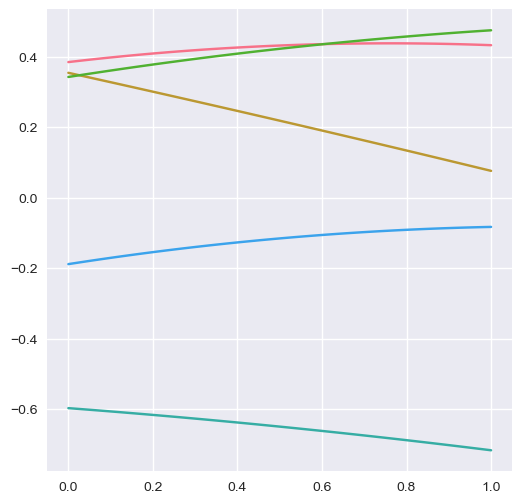

In [76]:
# PLot for early in the deck

num_lines = 5
intercepts = np.random.randn(num_lines)
slopes = 0.2*np.random.randn(num_lines)
quadratic = -0.1*np.random.rand(num_lines)

plt.figure(figsize=(6, 6))

_x = np.linspace(0, 1, 100)
for i in range(num_lines):
    _y = intercepts[i] + slopes[i]*_x + quadratic[i]*_x**2
    plt.plot(_x,_y,'-')




Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
[0.04523725 1.13010177]


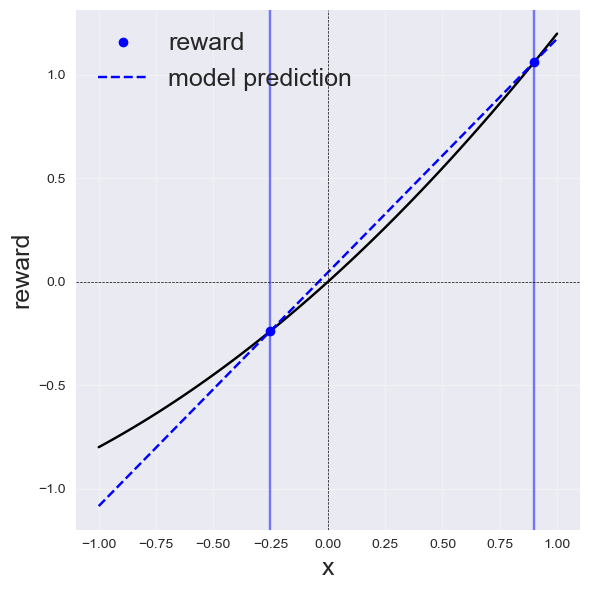

In [77]:
c = 0.2
np.random.seed(42)
n = 2

# Generate data
x = draw_x(n)
r = reward(x,c=c)
theta_hat_mse = fit_model_mse(x,r)
print(theta_hat_mse)

# Plot of x + cx^2 vs x
# _x and _r are x
_x = np.linspace(-1, 1, 100)
r_true = reward(_x,c=c)

r_hat_mse = theta_hat_mse[0] + theta_hat_mse[1]*_x

# Find the largest point in x that is below 0 
L = np.max(x[x<0])
U = np.min(x[x>0])



plt.figure(figsize=(6, 6))
plt.plot(_x, r_true, 'k-')
plt.plot(x, r, 'bo',label='reward')
plt.plot(_x, r_hat_mse, 'b--',label='model prediction')

plt.axvline(L,alpha=0.5,color='b')
plt.axvline(U,alpha=0.5,color='b')

plt.xlabel('x', fontsize=18)
plt.ylabel('reward', fontsize=18)
# plt.title('Plot of x + cx² vs x', fontsize=14, fontweight='bold')
# plt.legend(['reward', 'model prediction'],loc='best')
plt.legend(fontsize=18)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
plt.tight_layout()
# plt.savefig('plot_quadratic.png', dpi=150, bbox_inches='tight')
plt.show()

In [98]:

def get_expected_reward(thresh, c):
    _x = np.linspace(-1, 1, 100)
    return reward(_x[_x > thresh], c=c).sum() / len(_x)


def run_one_xp(n,c,seed):

    np.random.seed(seed)
    x = draw_x(n)
    x_tensor = torch.unsqueeze(torch.tensor(x), -1)
    r = reward(x_tensor,c=c)

    # run MSE
    theta_hat_mse = fit_model_esr(x_tensor, r)
    thresh_mse = -theta_hat_mse[0] / theta_hat_mse[1]

    # run ESR
    theta_hat_esr = fit_model_esr(x_tensor, r, alpha = 1, k = 1)
    thresh_esr = -theta_hat_esr[0] / theta_hat_esr[1]

    # run mix
    theta_hat_mix = fit_model_esr(x_tensor, r, alpha = 0.5, k = 1)
    thresh_mix = -theta_hat_mix[0] / theta_hat_mix[1]


    expected_reward_mse = get_expected_reward(thresh_mse, c)
    expected_reward_esr = get_expected_reward(thresh_esr, c)
    expected_reward_mix = get_expected_reward(thresh_mix, c)

    return expected_reward_mse, expected_reward_esr, expected_reward_mix

def run_xp(n,c,n_reps=10):

    mse = []
    esr = []
    mix = []

    for seed in range(n_reps):
        _mse, _esr, _mix = run_one_xp(n,c,seed)
        mse.append(_mse)
        esr.append(_esr)
        mix.append(_mix)

    return np.mean(mse), np.std(mse)/np.sqrt(n_reps), np.mean(esr), np.std(esr)/np.sqrt(n_reps), np.mean(mix), np.std(mix)/np.sqrt(n_reps)






In [99]:
df = pd.DataFrame(columns=['n', 'c', 'mse', 'mse_stderr', 'esr', 'esr_stderr', 'mix', 'mix_stderr'])

c = 0.2
for n in [2,4,8,16,32,64,128, 256, 512, 1024]:
    mse, mse_stderr, esr, esr_stderr, mix, mix_stderr = run_xp(n,c)
    df.loc[len(df)] = [n,c,mse,mse_stderr,esr,esr_stderr, mix, mix_stderr]

In [101]:
c = 0.4
for n in [2,4,8,16,32,64,128, 256, 512, 1024]:
    mse, mse_stderr, esr, esr_stderr, mix, mix_stderr = run_xp(n,c)
    df.loc[len(df)] = [n,c,mse,mse_stderr,esr,esr_stderr, mix, mix_stderr]

In [102]:
df

,n,c,mse,mse_stderr,esr,esr_stderr,mix,mix_stderr
0,2.0,0.2,0.285239,0.000348,0.121460,3.339768e-02,0.241421,0.026863
1,4.0,0.2,0.257269,0.027120,0.127186,3.404378e-02,0.261943,0.017620
2,8.0,0.2,0.284433,0.001130,0.194781,3.425229e-02,0.263482,0.007790
3,16.0,0.2,0.285671,0.000145,0.281997,1.479396e-03,0.285664,0.000193
4,32.0,0.2,0.285471,0.000121,0.285356,3.725463e-04,0.286130,0.000092
5,64.0,0.2,0.285610,0.000086,0.286391,4.307743e-05,0.286341,0.000044
6,128.0,0.2,0.285491,0.000088,0.286411,4.670119e-05,0.286311,0.000047
7,256.0,0.2,0.285560,0.000066,0.286462,3.774506e-05,0.286341,0.000044
8,512.0,0.2,0.285630,0.000000,0.286522,9.563301e-06,0.286492,0.000016
9,1024.0,0.2,0.285630,0.000000,0.286532,1.755417e-17,0.286472,0.000016


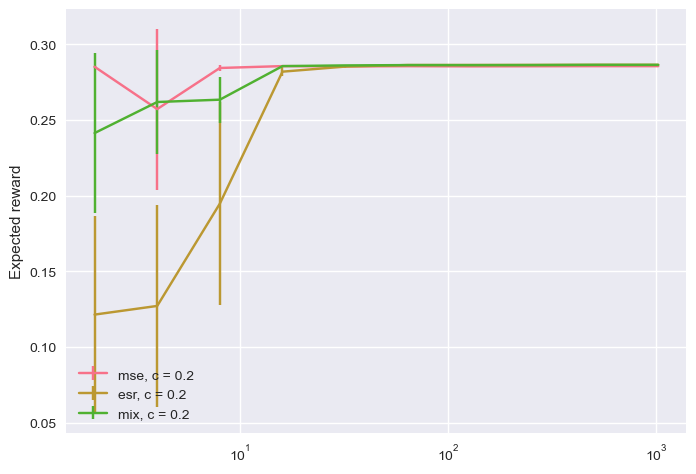

In [105]:
plt.errorbar(df[df['c'] == 0.2]['n'],df[df['c'] == 0.2]['mse'],1.96*df[df['c'] == 0.2]['mse_stderr'],label='mse, c = 0.2')
plt.errorbar(df[df['c'] == 0.2]['n'],df[df['c'] == 0.2]['esr'],1.96*df[df['c'] == 0.2]['esr_stderr'],label='esr, c = 0.2')
plt.errorbar(df[df['c'] == 0.2]['n'],df[df['c'] == 0.2]['mix'],1.96*df[df['c'] == 0.2]['mix_stderr'],label='mix, c = 0.2')
# plt.errorbar(df[df['c'] == 0.4]['n'],df[df['c'] == 0.4]['mse'],1.96*df[df['c'] == 0.4]['mse_stderr'],label='mse, c = 0.4')
# plt.errorbar(df[df['c'] == 0.4]['n'],df[df['c'] == 0.4]['esr'],1.96*df[df['c'] == 0.4]['esr_stderr'],label='esr, c = 0.4')
# plt.errorbar(df[df['c'] == 0.4]['n'],df[df['c'] == 0.4]['mix'],1.96*df[df['c'] == 0.4]['mix_stderr'],label='mix, c = 0.4')
plt.legend(loc='best')
plt.ylabel('Expected reward')
plt.xlabel('')
plt.xscale('log')

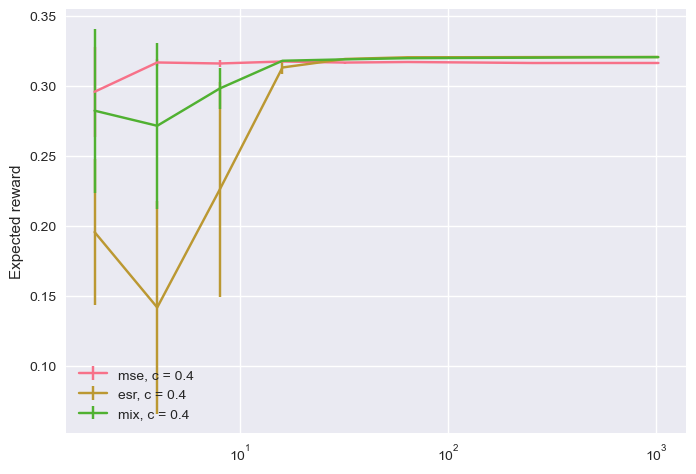

In [106]:
# plt.errorbar(df[df['c'] == 0.2]['n'],df[df['c'] == 0.2]['mse'],1.96*df[df['c'] == 0.2]['mse_stderr'],label='mse, c = 0.2')
# plt.errorbar(df[df['c'] == 0.2]['n'],df[df['c'] == 0.2]['esr'],1.96*df[df['c'] == 0.2]['esr_stderr'],label='esr, c = 0.2')
# plt.errorbar(df[df['c'] == 0.2]['n'],df[df['c'] == 0.2]['mix'],1.96*df[df['c'] == 0.2]['mix_stderr'],label='mix, c = 0.2')
plt.errorbar(df[df['c'] == 0.4]['n'],df[df['c'] == 0.4]['mse'],1.96*df[df['c'] == 0.4]['mse_stderr'],label='mse, c = 0.4')
plt.errorbar(df[df['c'] == 0.4]['n'],df[df['c'] == 0.4]['esr'],1.96*df[df['c'] == 0.4]['esr_stderr'],label='esr, c = 0.4')
plt.errorbar(df[df['c'] == 0.4]['n'],df[df['c'] == 0.4]['mix'],1.96*df[df['c'] == 0.4]['mix_stderr'],label='mix, c = 0.4')
plt.legend(loc='best')
plt.ylabel('Expected reward')
plt.xlabel('')
plt.xscale('log')

In [87]:
plt.close()

In [66]:
np.min(x[x>0])

np.float64(0.4406489868843162)

In [3]:
df = pd.read_csv('out2.csv',header=0)

In [4]:
df.head()

,train_loss,train_regret,test_regret,train_mse
0,3.977049,0.318541,0.317685,0.413507
1,3.206944,0.319097,0.316484,0.378763
2,0.057778,0.318714,0.316111,0.784322
3,3.125766,0.319097,0.316484,0.376514
4,3.046676,0.319097,0.316484,0.374393


In [5]:
df.columns

Index(['train_loss', 'train_regret', 'test_regret', 'train_mse'], dtype='object')

In [6]:
df['train_mse']

0     0.413507
1     0.378763
2     0.784322
3     0.376514
4     0.374393
        ...   
95    0.765783
96    0.769825
97    0.773837
98    0.777483
99    0.780955
Name: train_mse, Length: 100, dtype: float64

Text(0, 0.5, 'train_mse')

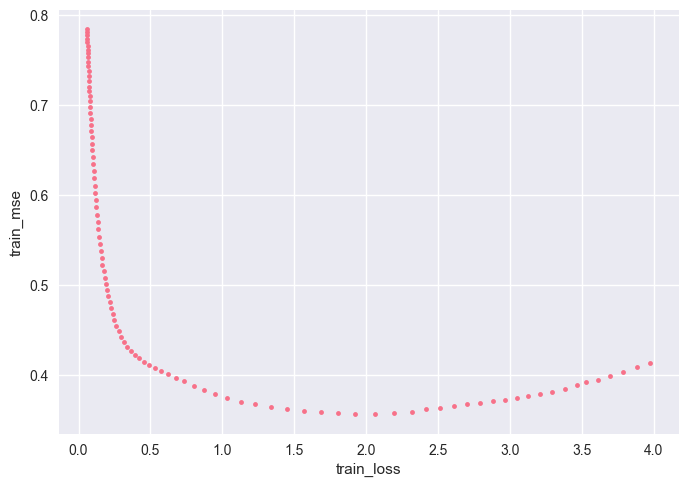

In [7]:
plt.plot(df['train_loss'],df['train_mse'],'.')
plt.xlabel('train_loss')
plt.ylabel('train_mse')

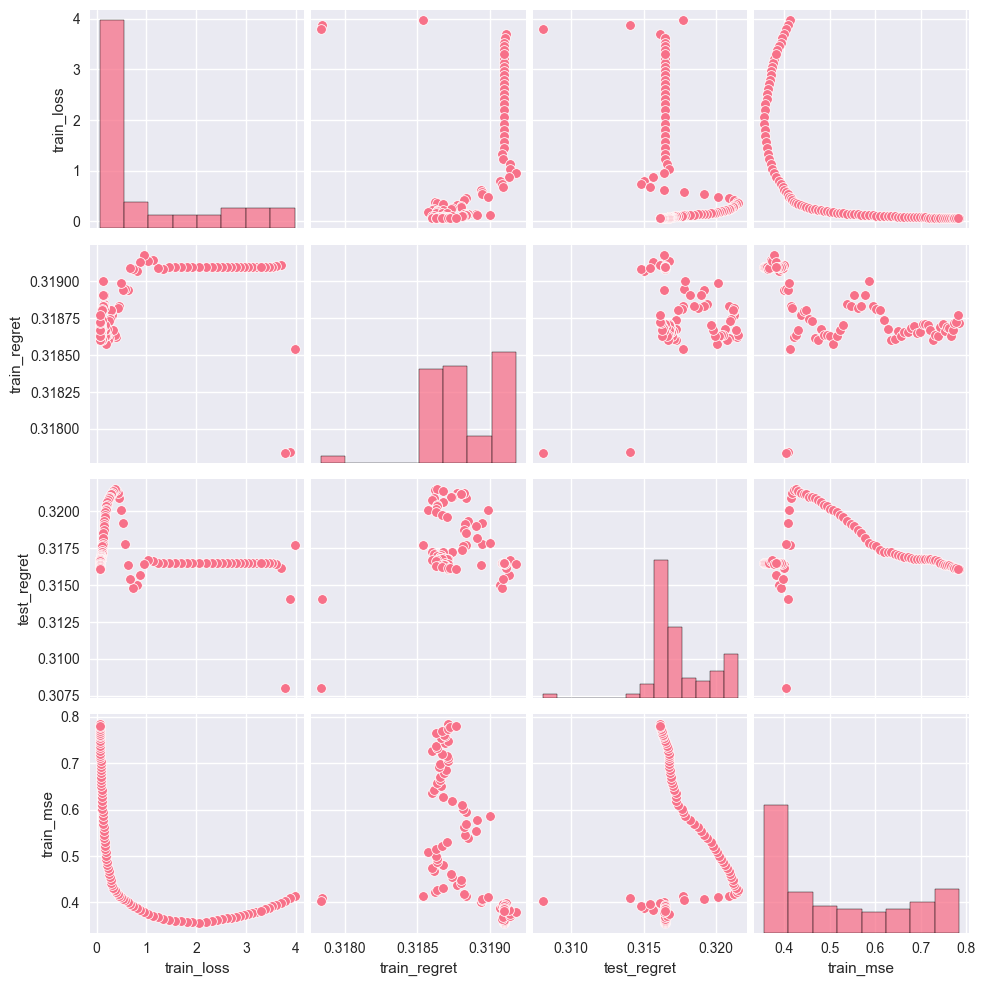

In [8]:
sns.pairplot(df)

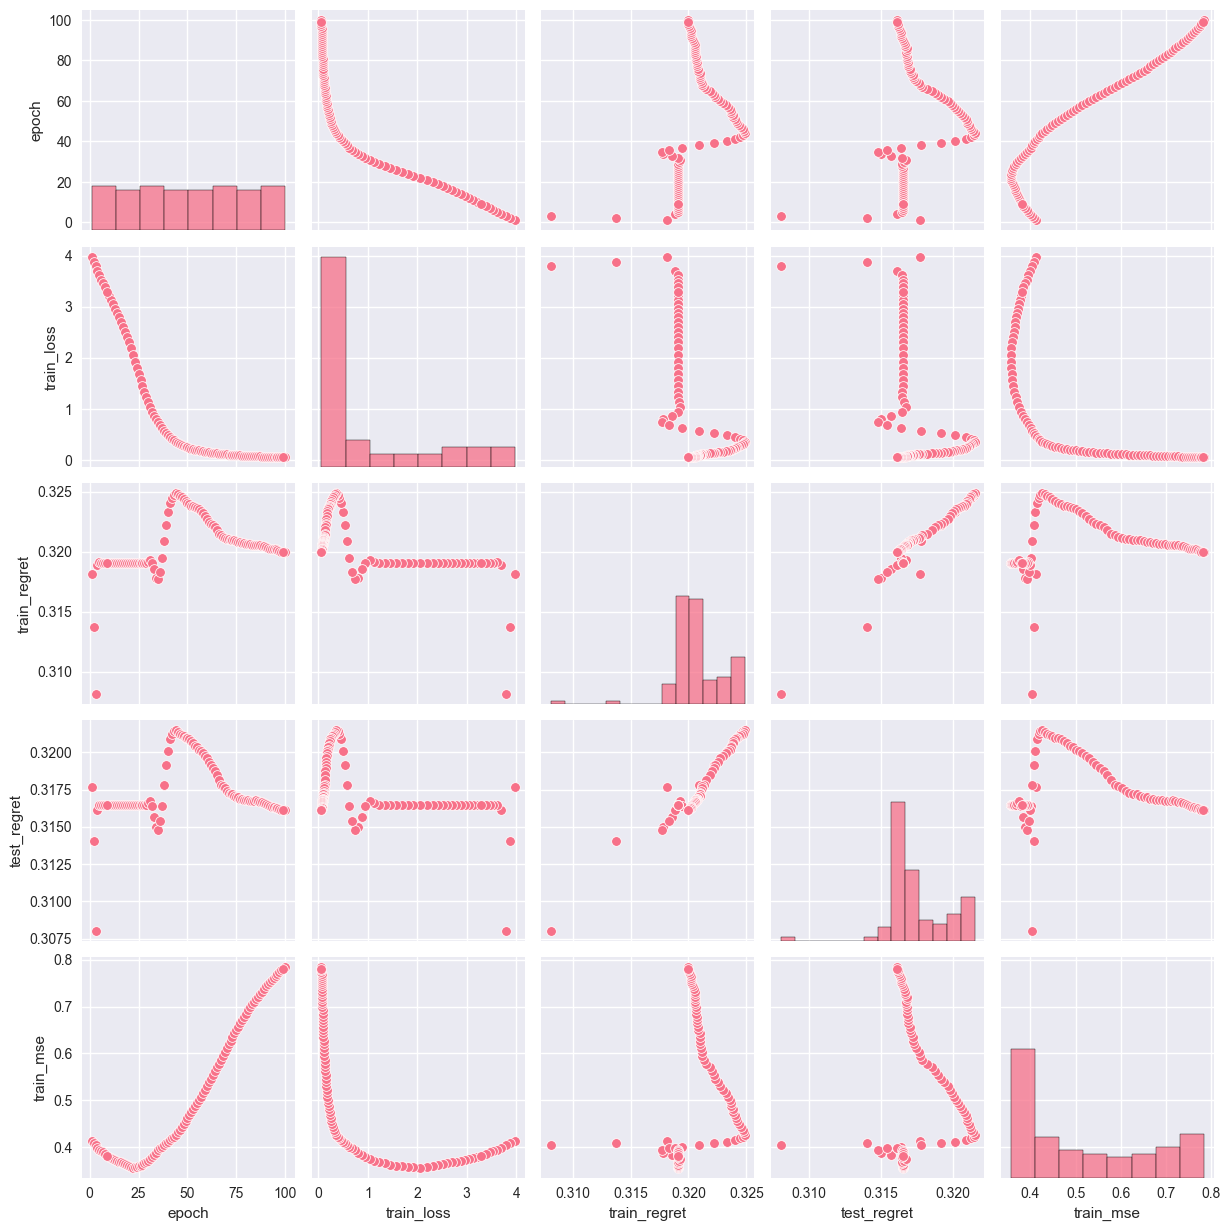

In [9]:
df1 = pd.read_csv('XP1.csv')
sns.pairplot(df1)

In [10]:

num_df = 21

df = [pd.DataFrame()]*num_df
for i in range(num_df):
    df[i] = pd.read_csv(f'XP{i+1:02d}.csv')

for i in range(num_df):
    test_regret = df[i]['test_regret'].iloc[-1]
    print(f'XP{i+1}, test_regret={test_regret}')

XP1, test_regret=0.316106
XP2, test_regret=0.318134
XP3, test_regret=0.313729
XP4, test_regret=0.312269
XP5, test_regret=0.335653
XP6, test_regret=0.342433
XP7, test_regret=0.317641
XP8, test_regret=0.31898
XP9, test_regret=0.318356
XP10, test_regret=0.307851
XP11, test_regret=0.318647
XP12, test_regret=0.318181
XP13, test_regret=0.324017
XP14, test_regret=0.311243
XP15, test_regret=0.330048
XP16, test_regret=0.321594
XP17, test_regret=0.314357
XP18, test_regret=0.328967
XP19, test_regret=0.316056
XP20, test_regret=0.315972
XP21, test_regret=0.332829


# Autogenerated stuff from Cursor -- probably discard

## Load Data and Setup


In [11]:
# Load test data for computing MSE
try:
    data = np.load('informs.npz')
    xs_train = data['xs_train']
    treats_train = data['treats_train']
    outcomes_train = data['outcomes_train']
    print(f"✓ Loaded data: {xs_train.shape[0]} training samples, {xs_train.shape[1]} features")
except FileNotFoundError:
    print("✗ Data file 'informs.npz' not found. Please ensure data is available.")
    # Create dummy data for demonstration
    np.random.seed(42)
    xs_train = np.random.randn(1000, 25)
    treats_train = np.random.binomial(1, 0.5, 1000)
    outcomes_train = np.random.randn(1000)
    print("⚠️  Using dummy data for demonstration")


✓ Loaded data: 100000 training samples, 50 features


## Load and Analyze Model Checkpoints


In [12]:
def load_and_analyze_models(model_save_dir="model_weights"):
    """Load model checkpoints and compute training metrics."""
    
    if not os.path.exists(model_save_dir):
        print(f"✗ Model directory '{model_save_dir}' not found!")
        return pd.DataFrame()
    
    model_files = glob.glob(os.path.join(model_save_dir, "*.pth"))
    
    if not model_files:
        print(f"✗ No model files found in '{model_save_dir}'!")
        return pd.DataFrame()
    
    print(f"✓ Found {len(model_files)} model files")
    
    results = []
    
    for model_file in sorted(model_files):
        filename = os.path.basename(model_file)
        print(f"  Analyzing: {filename}")
        
        try:
            # Load checkpoint
            checkpoint = torch.load(model_file, map_location='cpu', weights_only=False)
            
            # Extract metadata
            epoch = checkpoint.get('epoch', 0)
            train_loss = checkpoint.get('train_loss', 0)
            n_train = checkpoint.get('n_train', len(xs_train))
            k_param = checkpoint.get('k', None)
            
            # Determine model type from filename
            if "reg_learner" in filename:
                model_type = "reg_learner"
            elif "s_learner" in filename:
                model_type = "s_learner"
            elif "t_learner" in filename:
                model_type = "t_learner"
            elif "r_learner" in filename:
                model_type = "r_learner"
            elif "dr_learner" in filename:
                model_type = "dr_learner"
            else:
                model_type = "unknown"
            
            # Create model and compute training MSE
            _, d = xs_train.shape
            model = Net(d+1).to('cpu')
            model.load_state_dict(checkpoint['model_state_dict'])
            model.eval()
            
            # Compute training MSE
            with torch.no_grad():
                # Use subset of training data if specified
                n_train_actual = min(n_train, len(xs_train))
                xs_subset = xs_train[:n_train_actual]
                treats_subset = treats_train[:n_train_actual]
                outcomes_subset = outcomes_train[:n_train_actual]
                
                # Prepare input for model
                X_train = np.concatenate((xs_subset, np.expand_dims(treats_subset, axis=1)), axis=1)
                train_pred = model(torch.tensor(X_train, dtype=torch.float64)).numpy()
                
                # Compute MSE
                train_mse = mean_squared_error(outcomes_subset, train_pred)
            
            # Store results
            results.append({
                'filename': filename,
                'model_type': model_type,
                'epoch': epoch,
                'train_loss': train_loss,
                'train_mse': train_mse,
                'n_train': n_train_actual,
                'k_param': k_param
            })
            
        except Exception as e:
            print(f"    ✗ Error loading {filename}: {e}")
            continue
    
    return pd.DataFrame(results)

# Load models from default directory
df = load_and_analyze_models()
print(f"\n📊 Loaded {len(df)} model checkpoints")


✓ Found 100 model files
  Analyzing: reg_learner_epoch_1.pth
    ✗ Error loading reg_learner_epoch_1.pth: Error(s) in loading state_dict for Net:
	size mismatch for lin.weight: copying a param with shape torch.Size([5, 3]) from checkpoint, the shape in current model is torch.Size([5, 51]).
  Analyzing: reg_learner_epoch_10.pth
    ✗ Error loading reg_learner_epoch_10.pth: Error(s) in loading state_dict for Net:
	size mismatch for lin.weight: copying a param with shape torch.Size([5, 3]) from checkpoint, the shape in current model is torch.Size([5, 51]).
  Analyzing: reg_learner_epoch_100.pth
    ✗ Error loading reg_learner_epoch_100.pth: Error(s) in loading state_dict for Net:
	size mismatch for lin.weight: copying a param with shape torch.Size([5, 3]) from checkpoint, the shape in current model is torch.Size([5, 51]).
  Analyzing: reg_learner_epoch_11.pth
    ✗ Error loading reg_learner_epoch_11.pth: Error(s) in loading state_dict for Net:
	size mismatch for lin.weight: copying a para

## Display Results Table


In [13]:
if not df.empty:
    print("📋 Model Analysis Results:")
    print("=" * 80)
    
    # Display summary statistics
    print("\n📈 Summary Statistics:")
    print(df[['train_loss', 'train_mse']].describe())
    
    # Display detailed results
    print("\n📊 Detailed Results:")
    display(df[['filename', 'model_type', 'epoch', 'train_loss', 'train_mse', 'n_train', 'k_param']])
else:
    print("✗ No model data available for analysis")


✗ No model data available for analysis


## Create Training Loss vs Training MSE Plot


In [14]:
if not df.empty:
    # Create the main plot
    plt.figure(figsize=(12, 8))
    
    # Create scatter plot with different colors for different model types
    model_types = df['model_type'].unique()
    colors = plt.cm.Set1(np.linspace(0, 1, len(model_types)))
    
    for i, model_type in enumerate(model_types):
        mask = df['model_type'] == model_type
        subset = df[mask]
        
        plt.scatter(subset['train_loss'], subset['train_mse'], 
                   c=[colors[i]], label=f'{model_type} (n={len(subset)})', 
                   alpha=0.7, s=100, edgecolors='black', linewidth=0.5)
    
    # Add trend line
    if len(df) > 1:
        z = np.polyfit(df['train_loss'], df['train_mse'], 1)
        p = np.poly1d(z)
        plt.plot(df['train_loss'], p(df['train_loss']), 
                "r--", alpha=0.8, linewidth=2, label=f'Trend (slope={z[0]:.3f})')
    
    plt.xlabel('Training Loss', fontsize=14)
    plt.ylabel('Training MSE', fontsize=14)
    plt.title('Training Loss vs Training MSE\nModel Performance Analysis', fontsize=16, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    correlation = df['train_loss'].corr(df['train_mse'])
    plt.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
             transform=plt.gca().transAxes, fontsize=12, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    print(f"📊 Correlation between Training Loss and Training MSE: {correlation:.3f}")
else:
    print("✗ No data available for plotting")


✗ No data available for plotting
